In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Çalıştığın klasördeki dosyaları bir görelim 
print("Bulunduğun klasör:", os.getcwd())
print("Klasördeki dosyalar:", os.listdir())

# Yeni CSV dosyanın adı
file_path = "Road Accident Data.csv"   

# CSV'yi oku
df = pd.read_csv(file_path)

print("\n✅ Veri seti yüklendi.")
print("Satır, Sütun sayısı:", df.shape)

# İlk birkaç satıra bakalım
df.head()


Bulunduğun klasör: C:\Users\ibrah\ing.kaza.tahmini
Klasördeki dosyalar: ['.ipynb_checkpoints', 'app.py', 'df_model_hazır.csv', 'df_model_hazır2.csv', 'df_model_hazır3.csv', 'EDA-preprocessing.ipynb', 'feature_columns.pkl', 'final_xgb.pkl', 'lazypredict.ipynb', 'model2.ipynb', 'model_.ipynb', 'processed_v2.csv', 'Road Accident Data.csv']

✅ Veri seti yüklendi.
Satır, Sütun sayısı: (307973, 21)


,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [4]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Day_of_Week                 307973 non-null  object 
 3   Junction_Control            307973 non-null  object 
 4   Junction_Detail             307973 non-null  object 
 5   Accident_Severity           307973 non-null  object 
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  object 
 8   Local_Authority_(District)  307973 non-null  object 
 9   Carriageway_Hazards         5424 non-null    object 
 10  Longitude                   307973 non-null  float64
 11  Number_of_Casualties        307973 non-null  int64  
 12  Number_of_Vehicles          307973 non-null  int64  
 13  Police_Force  

In [5]:
for col in df.select_dtypes(include='object').columns:
    try:
        pd.to_numeric(df[col])
        print(col, " -> Sayısal olabilir")
    except:
        pass


In [6]:
df.isnull().mean().sort_values(ascending=False)


Carriageway_Hazards           0.982388
Weather_Conditions            0.019667
Road_Type                     0.004981
Road_Surface_Conditions       0.001029
Time                          0.000055
Accident_Index                0.000000
Number_of_Casualties          0.000000
Urban_or_Rural_Area           0.000000
Speed_limit                   0.000000
Police_Force                  0.000000
Number_of_Vehicles            0.000000
Longitude                     0.000000
Accident Date                 0.000000
Local_Authority_(District)    0.000000
Light_Conditions              0.000000
Latitude                      0.000000
Accident_Severity             0.000000
Junction_Detail               0.000000
Junction_Control              0.000000
Day_of_Week                   0.000000
Vehicle_Type                  0.000000
dtype: float64

In [7]:
print("Satır, Sütun:", df.shape)
print(df.columns)


Satır, Sütun: (307973, 21)
Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')


In [8]:
df['Accident_Severity'].unique()


array(['Serious', 'Slight', 'Fetal', 'Fatal'], dtype=object)

In [9]:
df_other = df[df["Accident_Severity"] == "Other"]
df_other.shape


(0, 21)

In [10]:
df['Accident_Severity'].value_counts()


Accident_Severity
Slight     263280
Serious     40740
Fatal        3904
Fetal          49
Name: count, dtype: int64

In [11]:
df = df[df['Accident_Severity'] != 'Fatal']


In [12]:
df['Accident_Severity'] = df['Accident_Severity'].replace({
    'Fatal': 'Serious'
})


Severity_3
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64
Severity_3
Slight     85.488014
Serious    13.228432
Fatal       1.283554
Name: count, dtype: float64


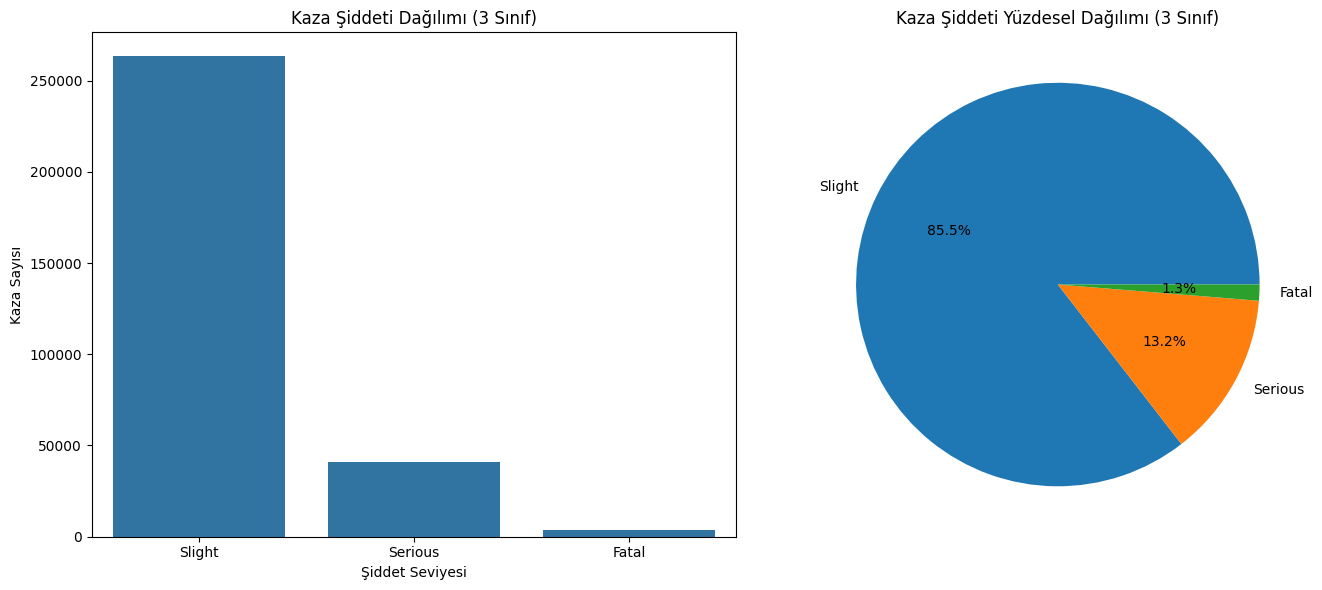

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Road Accident Data.csv")

# Fatal yazım hatasını düzelt
df['Accident_Severity'] = df['Accident_Severity'].replace({'Fetal': 'Fatal'})

# Slight veya Serious değilse Fatal yap
df['Severity_3'] = df['Accident_Severity'].where(
    df['Accident_Severity'].isin(['Slight', 'Serious']),
    'Fatal'
)

severity_counts = df['Severity_3'].value_counts()
severity_percent = severity_counts / severity_counts.sum() * 100

print(severity_counts)
print(severity_percent)

order = ['Slight', 'Serious', 'Fatal']
order = [o for o in order if o in severity_counts.index]

plt.figure(figsize=(14,6))

# Bar chart
plt.subplot(1,2,1)
sns.countplot(x='Severity_3', data=df, order=order)
plt.title("Kaza Şiddeti Dağılımı (3 Sınıf)")
plt.xlabel("Şiddet Seviyesi")
plt.ylabel("Kaza Sayısı")

# Pie chart
plt.subplot(1,2,2)
plt.pie(
    [severity_counts[o] for o in order],
    labels=order,
    autopct='%1.1f%%'
)
plt.title("Kaza Şiddeti Yüzdesel Dağılımı (3 Sınıf)")

plt.tight_layout()
plt.show()
# sutun ve pasta

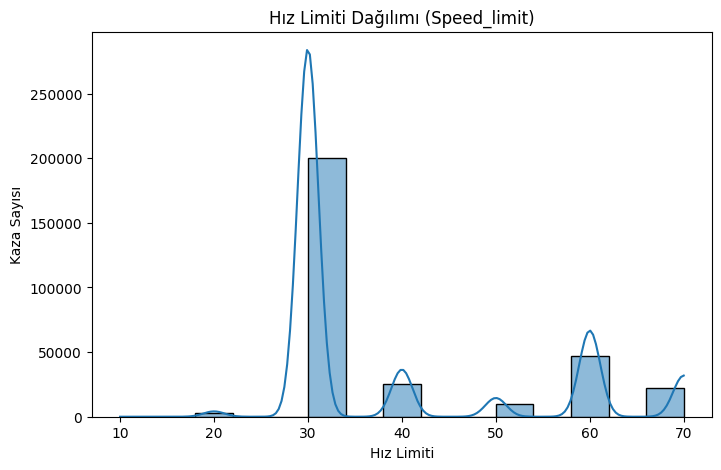

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Speed_limit'], bins=15, kde=True)
plt.title("Hız Limiti Dağılımı (Speed_limit)")
plt.xlabel("Hız Limiti")
plt.ylabel("Kaza Sayısı")
plt.show()
# histogram

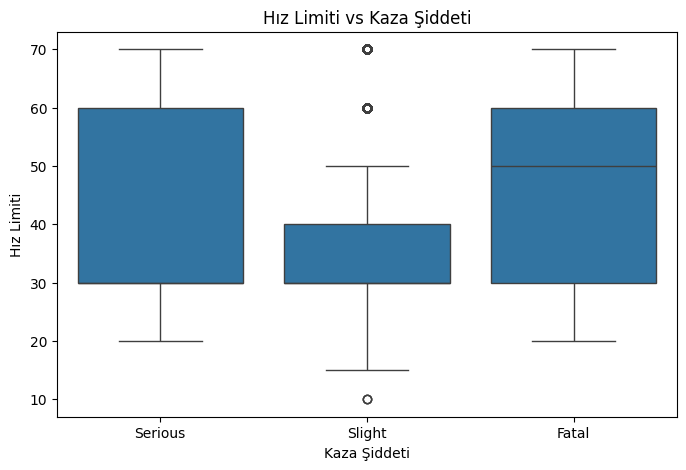

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Accident_Severity'], y=df['Speed_limit'])
plt.title("Hız Limiti vs Kaza Şiddeti")
plt.xlabel("Kaza Şiddeti")
plt.ylabel("Hız Limiti")
plt.show()
# BOXPLOT kutu grafigi

In [16]:
df['Accident_Severity'].value_counts()


Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64

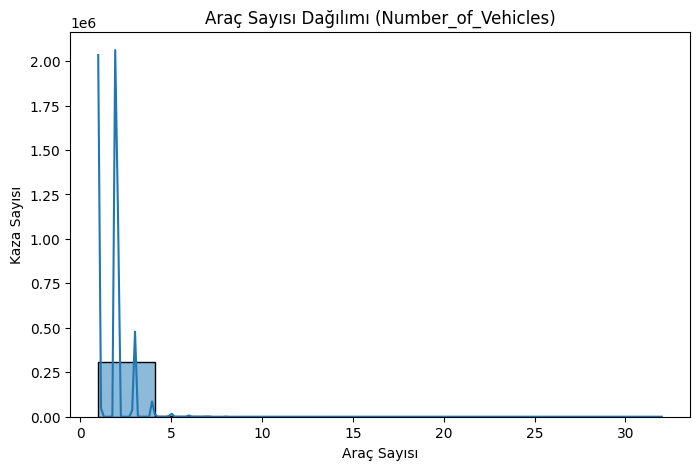

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Number_of_Vehicles'], bins=10, kde=True)
plt.title("Araç Sayısı Dağılımı (Number_of_Vehicles)")
plt.xlabel("Araç Sayısı")
plt.ylabel("Kaza Sayısı")
plt.show()
# histogram

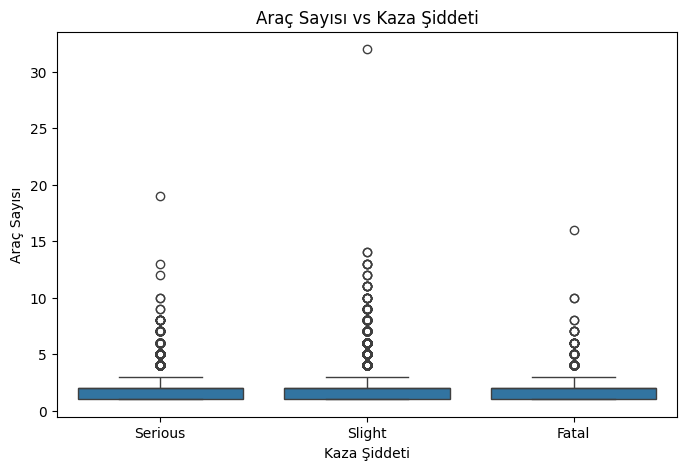

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Severity_3'], y=df['Number_of_Vehicles'])
plt.title("Araç Sayısı vs Kaza Şiddeti")
plt.xlabel("Kaza Şiddeti")
plt.ylabel("Araç Sayısı")
plt.show()


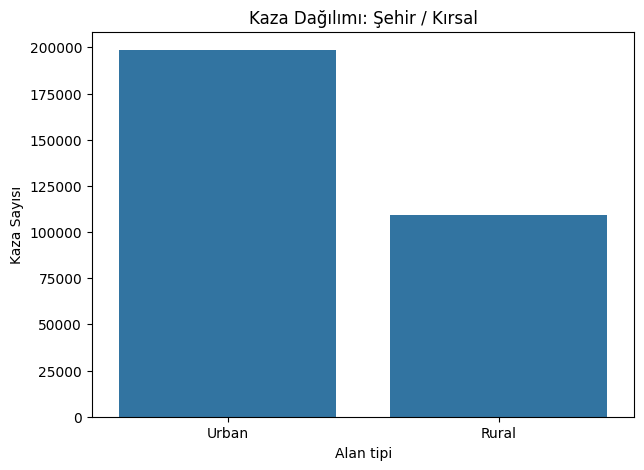

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(x='Urban_or_Rural_Area', data=df)
plt.title("Kaza Dağılımı: Şehir / Kırsal")
plt.xlabel("Alan tipi")
plt.ylabel("Kaza Sayısı")
plt.show()


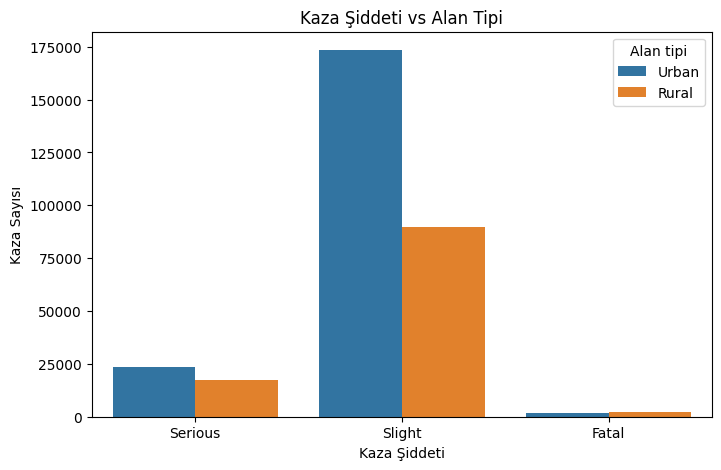

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Severity_3', hue='Urban_or_Rural_Area', data=df)
plt.title("Kaza Şiddeti vs Alan Tipi")
plt.xlabel("Kaza Şiddeti")
plt.ylabel("Kaza Sayısı")
plt.legend(title="Alan tipi")
plt.show()


In [21]:
df["Weather_Conditions"].value_counts(normalize=True) * 100

Weather_Conditions
Fine no high winds       80.981465
Raining no high winds    11.551889
Other                     2.915380
Snowing no high winds     1.602764
Raining + high winds      1.167875
Fine + high winds         1.042674
Fog or mist               0.559758
Snowing + high winds      0.178195
Name: proportion, dtype: float64

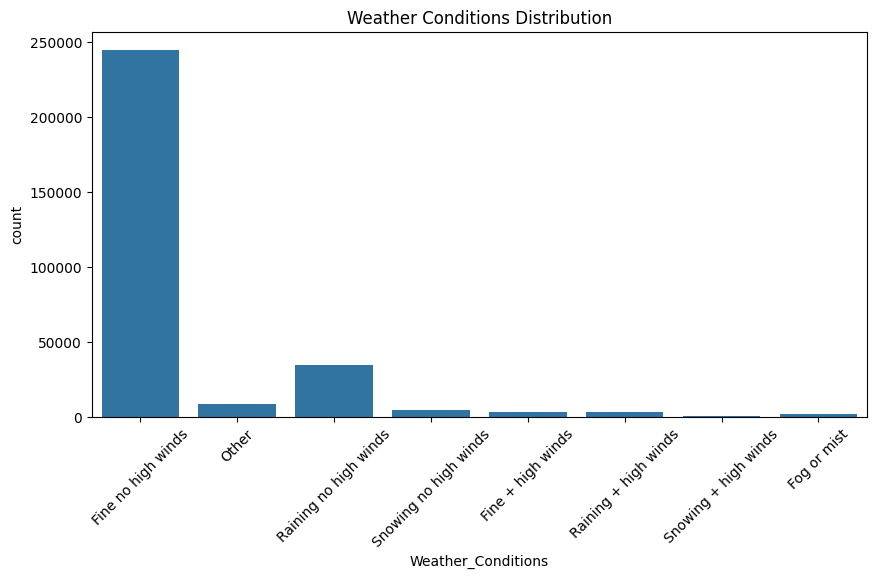

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Weather_Conditions")
plt.xticks(rotation=45)
plt.title("Weather Conditions Distribution")
plt.show()

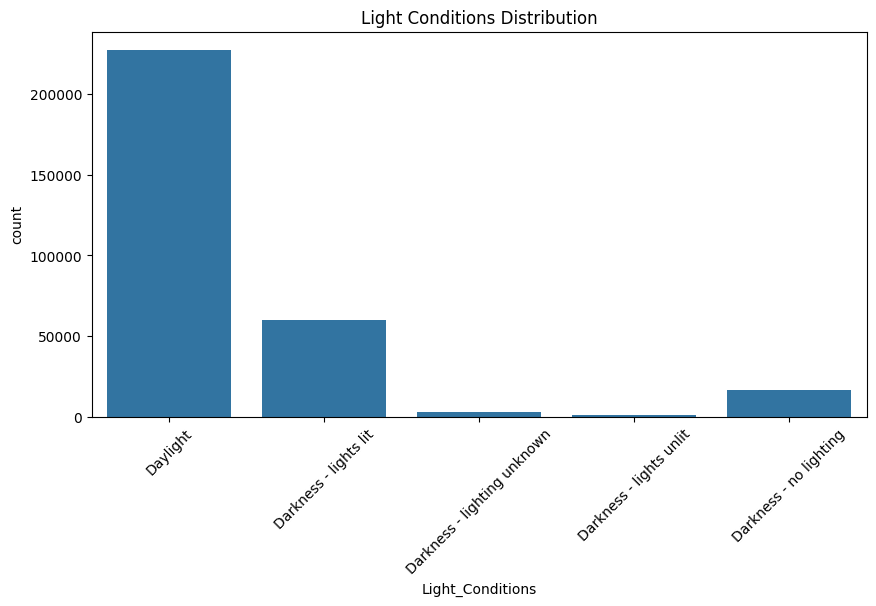

In [23]:
df["Light_Conditions"].value_counts(normalize=True) * 100
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Light_Conditions")
plt.xticks(rotation=45)
plt.title("Light Conditions Distribution")
plt.show()

In [24]:
df["Road_Surface_Conditions"].value_counts(normalize=True) * 100

Road_Surface_Conditions
Dry                     67.922290
Wet or damp             26.483800
Frost or ice             3.925813
Snow                     1.546532
Flood over 3cm. deep     0.121564
Name: proportion, dtype: float64

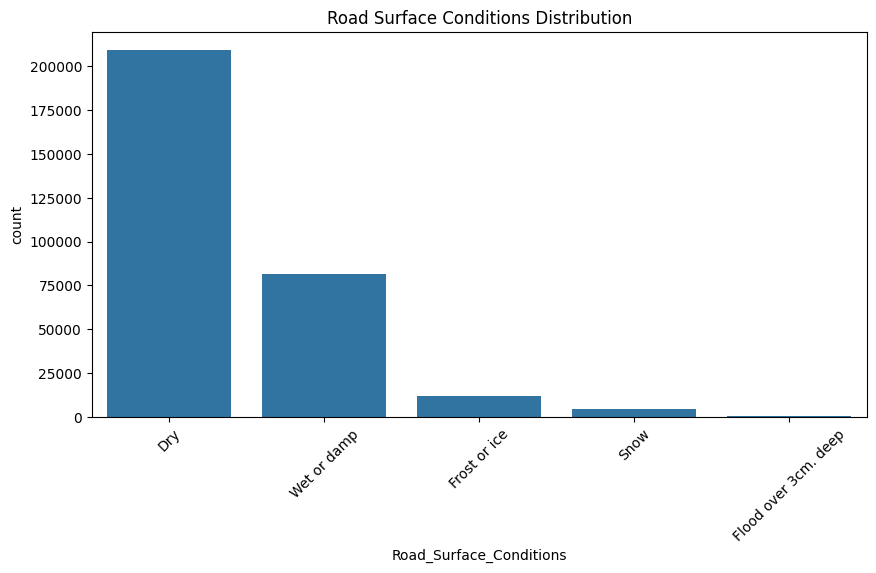

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Road_Surface_Conditions")
plt.xticks(rotation=45)
plt.title("Road Surface Conditions Distribution")
plt.show()

In [26]:
df["Road_Type"].value_counts(normalize=True) * 100

Road_Type
Single carriageway    75.255434
Dual carriageway      14.837211
Roundabout             6.829744
One way street         2.022262
Slip road              1.055349
Name: proportion, dtype: float64

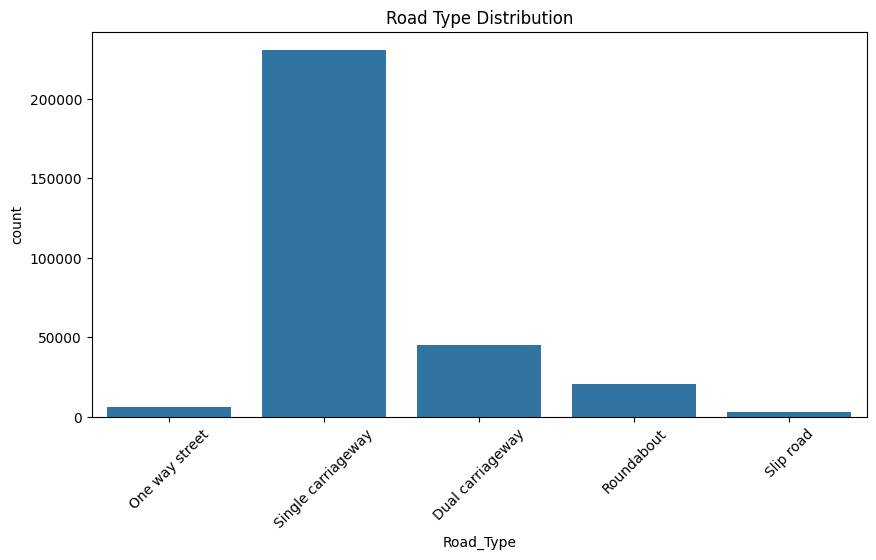

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Road_Type")
plt.xticks(rotation=45)
plt.title("Road Type Distribution")
plt.show()

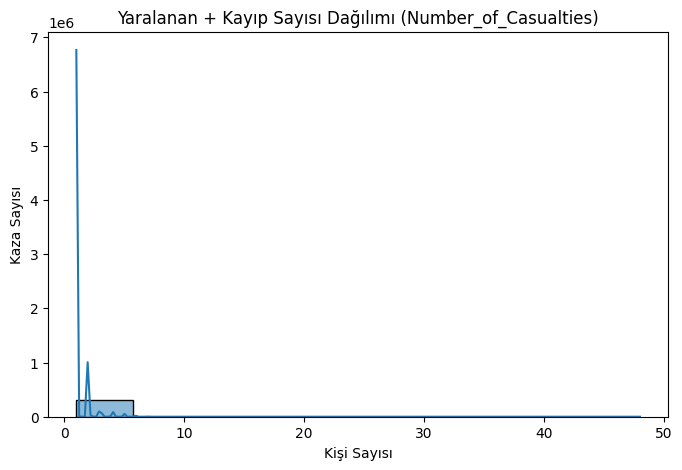

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['Number_of_Casualties'], bins=10, kde=True)
plt.title("Yaralanan + Kayıp Sayısı Dağılımı (Number_of_Casualties)")
plt.xlabel("Kişi Sayısı")
plt.ylabel("Kaza Sayısı")
plt.show()


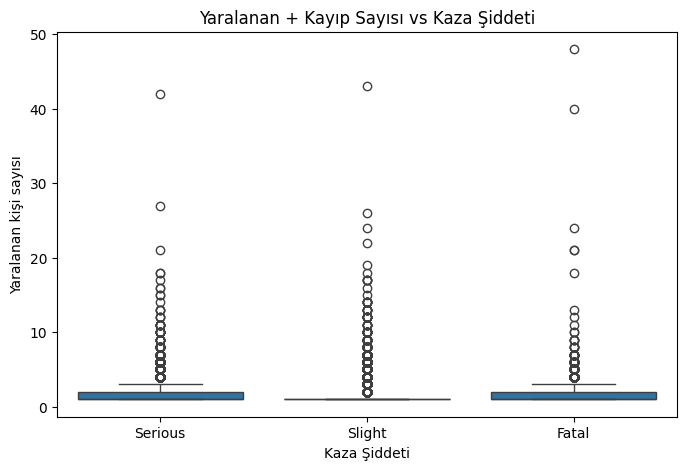

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Severity_3'], y=df['Number_of_Casualties'])
plt.title("Yaralanan + Kayıp Sayısı vs Kaza Şiddeti")
plt.xlabel("Kaza Şiddeti")
plt.ylabel("Yaralanan kişi sayısı")
plt.show()


In [30]:
df_corr = df.copy()

severity_map = {
    "Slight": 1,
    "Serious": 2,
    "Fatal": 3
}

df_corr["Severity_num"] = df_corr["Severity_3"].map(severity_map)


In [31]:
numeric_cols = [
    "Latitude",
    "Longitude",
    "Speed_limit",
    "Number_of_Casualties",
    "Number_of_Vehicles",
    "Severity_num"   # TARGET
]


In [32]:
corr = df_corr[numeric_cols].corr()


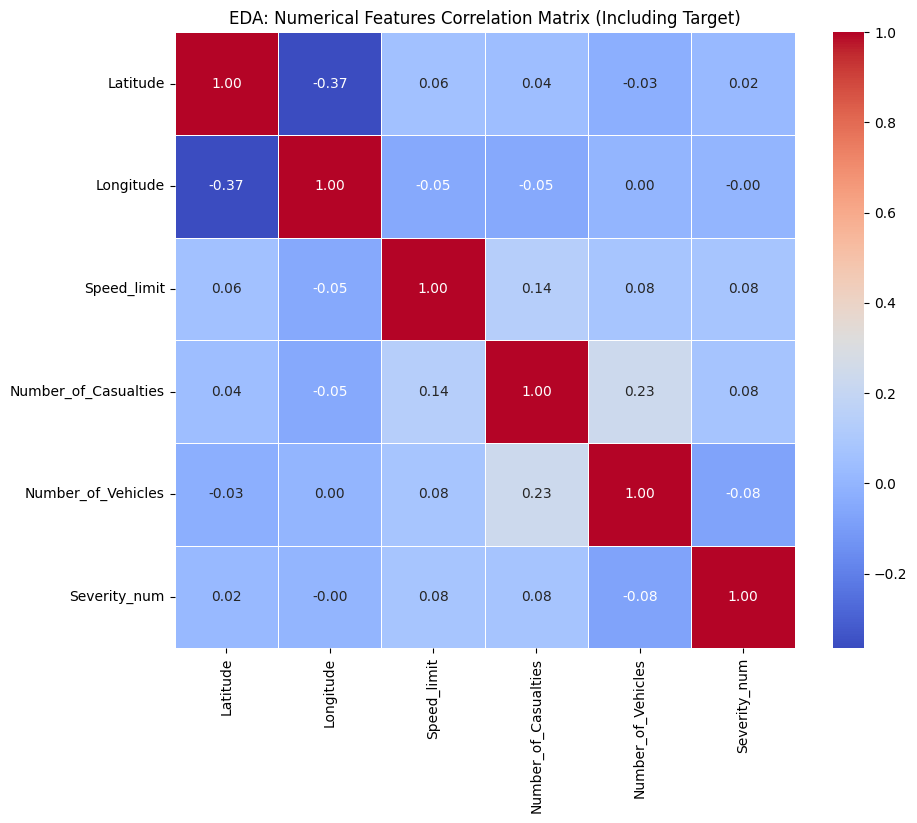

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("EDA: Numerical Features Correlation Matrix (Including Target)")
plt.show()


In [ ]:
# PREPROCESSING
# PREPROCESSING
# PREPROCESSING
# PREPROCESSING
# PREPROCESSING
# PREPROCESSING
# PREPROCESSING
# PREPROCESSING
# PREPROCESSING

In [ ]:
df.isnull().sum()


In [60]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,307973.0,52.487005,1.339011,49.914488,51.485248,52.225943,53.415517,60.598055
Longitude,307973.0,-1.368884,1.356092,-7.516225,-2.247937,-1.349258,-0.206810,1.759398
Number_of_Casualties,307973.0,1.356882,0.815857,1.000000,1.000000,1.000000,1.000000,48.000000
Number_of_Vehicles,307973.0,1.829063,0.710477,1.000000,1.000000,2.000000,2.000000,32.000000
Speed_limit,307973.0,38.866037,14.032933,10.000000,30.000000,30.000000,50.000000,70.000000


In [61]:
df.isnull().sum()
df.isnull().mean() * 100


Accident_Index                 0.000000
Accident Date                  0.000000
Day_of_Week                    0.000000
Junction_Control               0.000000
Junction_Detail                0.000000
Accident_Severity              0.000000
Latitude                       0.000000
Light_Conditions               0.000000
Local_Authority_(District)     0.000000
Carriageway_Hazards           98.238807
Longitude                      0.000000
Number_of_Casualties           0.000000
Number_of_Vehicles             0.000000
Police_Force                   0.000000
Road_Surface_Conditions        0.102931
Road_Type                      0.498096
Speed_limit                    0.000000
Time                           0.005520
Urban_or_Rural_Area            0.000000
Weather_Conditions             1.966731
Vehicle_Type                   0.000000
Severity_3                     0.000000
dtype: float64

In [62]:
df.drop(columns=['Carriageway_Hazards'], inplace=True)


In [63]:
mode_value = df['Road_Surface_Conditions'].mode()[0]   # en sık değer

df['Road_Surface_Conditions'] = df['Road_Surface_Conditions'].fillna(mode_value)

print("Doldurma tamamlandı. Mode:", mode_value)
df['Road_Surface_Conditions'].isnull().sum()


Doldurma tamamlandı. Mode: Dry


0

In [64]:
mode_weather = df['Weather_Conditions'].mode()[0]

df['Weather_Conditions'] = df['Weather_Conditions'].fillna(mode_weather)

print("Mode:", mode_weather)
df['Weather_Conditions'].isnull().sum()


Mode: Fine no high winds


0

In [65]:
df.isnull().sum()

Accident_Index                   0
Accident Date                    0
Day_of_Week                      0
Junction_Control                 0
Junction_Detail                  0
Accident_Severity                0
Latitude                         0
Light_Conditions                 0
Local_Authority_(District)       0
Longitude                        0
Number_of_Casualties             0
Number_of_Vehicles               0
Police_Force                     0
Road_Surface_Conditions          0
Road_Type                     1534
Speed_limit                      0
Time                            17
Urban_or_Rural_Area              0
Weather_Conditions               0
Vehicle_Type                     0
Severity_3                       0
dtype: int64

In [66]:
mode_road = df['Road_Type'].mode()[0]
df['Road_Type'] = df['Road_Type'].fillna(mode_road)

print("Mode:", mode_road)


Mode: Single carriageway


In [67]:
mode_time = df['Time'].mode()[0]
df['Time'] = df['Time'].fillna(mode_time)

print("Mode Time:", mode_time)


Mode Time: 17:00


In [68]:
df.isnull().sum()

Accident_Index                0
Accident Date                 0
Day_of_Week                   0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
Severity_3                    0
dtype: int64

In [69]:
def outlier_thresholds(dataframe, variable):
    q1 = dataframe[variable].quantile(0.25)
    q3 = dataframe[variable].quantile(0.75)
    iqr = q3 - q1
    low_limit = q1 - 1.5 * iqr
    up_limit  = q3 + 1.5 * iqr
    return low_limit, up_limit


def replace_with_thresholds(df, variable):
    low, up = outlier_thresholds(df, variable)

    df.loc[df[variable] < low, variable] = low
    df.loc[df[variable] > up, variable] = up

    print(f"{variable} → Outlier temizlendi.")


In [70]:
cols_to_fix = ["Number_of_Casualties", "Number_of_Vehicles"]

for col in cols_to_fix:
    replace_with_thresholds(df, col)


Number_of_Casualties → Outlier temizlendi.
Number_of_Vehicles → Outlier temizlendi.


In [71]:
def check_outliers(df, variable):
    low, up = outlier_thresholds(df, variable)
    outlier_mask = (df[variable] < low) | (df[variable] > up)
    print(variable, "→ outlier sayısı:", outlier_mask.sum())

for col in cols_to_fix:
    check_outliers(df, col)


Number_of_Casualties → outlier sayısı: 0
Number_of_Vehicles → outlier sayısı: 0


In [72]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,307973.0,52.487005,1.339011,49.914488,51.485248,52.225943,53.415517,60.598055
Longitude,307973.0,-1.368884,1.356092,-7.516225,-2.247937,-1.349258,-0.206810,1.759398
Number_of_Casualties,307973.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Number_of_Vehicles,307973.0,1.808689,0.628390,1.000000,1.000000,2.000000,2.000000,3.500000
Speed_limit,307973.0,38.866037,14.032933,10.000000,30.000000,30.000000,50.000000,70.000000


In [73]:
df['Number_of_Casualties'].value_counts()


Number_of_Casualties
1    307973
Name: count, dtype: int64

In [74]:
df_original = pd.read_csv("Road Accident Data.csv")
df_original['Number_of_Casualties'].value_counts()


Number_of_Casualties
1     235093
2      50088
3      14338
4       5348
5       1896
6        713
7        242
8        102
9         44
10        34
12        15
11        14
13        10
14         8
17         5
18         4
21         3
16         3
15         3
24         2
19         1
27         1
48         1
40         1
26         1
22         1
42         1
43         1
Name: count, dtype: int64

In [75]:
df['Number_of_Casualties'] = df_original['Number_of_Casualties']


In [76]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,307973.0,52.487005,1.339011,49.914488,51.485248,52.225943,53.415517,60.598055
Longitude,307973.0,-1.368884,1.356092,-7.516225,-2.247937,-1.349258,-0.206810,1.759398
Number_of_Casualties,307973.0,1.356882,0.815857,1.000000,1.000000,1.000000,1.000000,48.000000
Number_of_Vehicles,307973.0,1.808689,0.628390,1.000000,1.000000,2.000000,2.000000,3.500000
Speed_limit,307973.0,38.866037,14.032933,10.000000,30.000000,30.000000,50.000000,70.000000


In [77]:
df_model = df.copy()  # orijinali kalsın

df_model = df_model.drop(columns=["Accident_Index"])


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Day_of_Week                 307973 non-null  object 
 3   Junction_Control            307973 non-null  object 
 4   Junction_Detail             307973 non-null  object 
 5   Accident_Severity           307973 non-null  object 
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  object 
 8   Local_Authority_(District)  307973 non-null  object 
 9   Longitude                   307973 non-null  float64
 10  Number_of_Casualties        307973 non-null  int64  
 11  Number_of_Vehicles          307973 non-null  float64
 12  Police_Force                307973 non-null  object 
 13  Road_Surface_C

In [79]:
df_model = df.copy()
df_model = df_model.drop(columns=["Accident_Index"])


In [81]:
df_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident Date               307973 non-null  object 
 1   Day_of_Week                 307973 non-null  object 
 2   Junction_Control            307973 non-null  object 
 3   Junction_Detail             307973 non-null  object 
 4   Accident_Severity           307973 non-null  object 
 5   Latitude                    307973 non-null  float64
 6   Light_Conditions            307973 non-null  object 
 7   Local_Authority_(District)  307973 non-null  object 
 8   Longitude                   307973 non-null  float64
 9   Number_of_Casualties        307973 non-null  int64  
 10  Number_of_Vehicles          307973 non-null  float64
 11  Police_Force                307973 non-null  object 
 12  Road_Surface_Conditions     307973 non-null  object 
 13  Road_Type     

In [82]:
# Tarih kolonunu datetime'a çevir
df_model["Accident_Date"] = pd.to_datetime(df_model["Accident Date"])

# Yıl, ay, gün
df_model["Year"] = df_model["Accident_Date"].dt.year
df_model["Month"] = df_model["Accident_Date"].dt.month
df_model["Day"] = df_model["Accident_Date"].dt.day

# Haftanın günü (0=mon, 6=sun)
df_model["Weekday"] = df_model["Accident_Date"].dt.weekday

# Season değişkeni için fonksiyon
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df_model["Season"] = df_model["Month"].apply(get_season)

# kontrol edelim
df_model[["Accident_Date","Year","Month","Day","Weekday","Season"]].head()


,Accident_Date,Year,Month,Day,Weekday,Season
0,2021-01-01,2021,1,1,4,Winter
1,2021-01-05,2021,1,5,1,Winter
2,2021-01-04,2021,1,4,0,Winter
3,2021-01-05,2021,1,5,1,Winter
4,2021-01-06,2021,1,6,2,Winter


In [83]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Accident Date               307973 non-null  object        
 1   Day_of_Week                 307973 non-null  object        
 2   Junction_Control            307973 non-null  object        
 3   Junction_Detail             307973 non-null  object        
 4   Accident_Severity           307973 non-null  object        
 5   Latitude                    307973 non-null  float64       
 6   Light_Conditions            307973 non-null  object        
 7   Local_Authority_(District)  307973 non-null  object        
 8   Longitude                   307973 non-null  float64       
 9   Number_of_Casualties        307973 non-null  int64         
 10  Number_of_Vehicles          307973 non-null  float64       
 11  Police_Force                307973 non-

In [84]:
df_model["Time"] = pd.to_datetime(df_model["Time"], format="%H:%M", errors="coerce")
df_model["Hour"] = df_model["Time"].dt.hour


In [85]:
df_model["Hour"].isnull().sum()


0

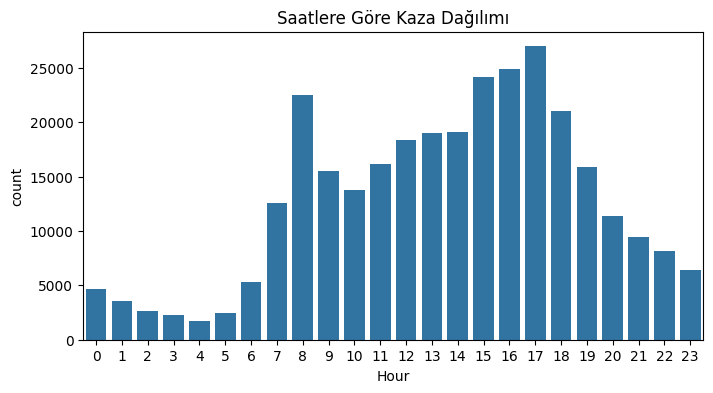

In [88]:
plt.figure(figsize=(8,4))
sns.countplot(x="Hour", data=df_model)
plt.title("Saatlere Göre Kaza Dağılımı")
plt.show()


In [89]:
df_model[["Hour"]].head()

,Hour
0,15
1,10
2,14
3,8
4,17


In [90]:
df_model["Is_Rush_Hour"] = df_model["Hour"].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0
)


In [91]:
df_model["Is_Rush_Hour"].value_counts()


Is_Rush_Hour
0    168503
1    139470
Name: count, dtype: int64

In [92]:
df_model["Is_Rush_Hour"].value_counts(normalize=True) * 100


Is_Rush_Hour
0    54.713563
1    45.286437
Name: proportion, dtype: float64

In [93]:
pd.crosstab(df_model["Is_Rush_Hour"], df_model["Severity_3"], normalize="index")


Severity_3,Fatal,Serious,Slight
Is_Rush_Hour,,,
0,0.014878,0.138211,0.846911
1,0.010368,0.125124,0.864508


In [94]:
df_model.drop(columns=["Accident Date"], inplace=True)

In [95]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Day_of_Week                 307973 non-null  object        
 1   Junction_Control            307973 non-null  object        
 2   Junction_Detail             307973 non-null  object        
 3   Accident_Severity           307973 non-null  object        
 4   Latitude                    307973 non-null  float64       
 5   Light_Conditions            307973 non-null  object        
 6   Local_Authority_(District)  307973 non-null  object        
 7   Longitude                   307973 non-null  float64       
 8   Number_of_Casualties        307973 non-null  int64         
 9   Number_of_Vehicles          307973 non-null  float64       
 10  Police_Force                307973 non-null  object        
 11  Road_Surface_Conditions     307973 non-

In [96]:
Accident_Date               307973 non-null  datetime64[ns]

SyntaxError: invalid syntax (3710357847.py, line 1)

In [98]:
df_model.columns


Index(['Day_of_Week', 'Junction_Control', 'Junction_Detail',
       'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Longitude', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions',
       'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area',
       'Weather_Conditions', 'Vehicle_Type', 'Severity_3', 'Accident_Date',
       'Year', 'Month', 'Day', 'Weekday', 'Season', 'Hour', 'Is_Rush_Hour'],
      dtype='object')

In [99]:
df_model["Accident_Date"].head(10)



0   2021-01-01
1   2021-01-05
2   2021-01-04
3   2021-01-05
4   2021-01-06
5   2021-01-01
6   2021-01-08
7   2021-01-02
8   2021-01-07
9   2021-01-10
Name: Accident_Date, dtype: datetime64[ns]

In [100]:
df_model["Accident_Date"].dtype


dtype('<M8[ns]')

In [101]:
df_model["Day_of_Week"].head(10)

0     Thursday
1       Monday
2       Sunday
3       Monday
4      Tuesday
5     Thursday
6     Thursday
7       Friday
8    Wednesday
9     Saturday
Name: Day_of_Week, dtype: object

In [104]:
 df_model["Police_Force"].head(50)

0     Metropolitan Police
1     Metropolitan Police
2     Metropolitan Police
3     Metropolitan Police
4     Metropolitan Police
5     Metropolitan Police
6     Metropolitan Police
7     Metropolitan Police
8     Metropolitan Police
9     Metropolitan Police
10    Metropolitan Police
11    Metropolitan Police
12    Metropolitan Police
13    Metropolitan Police
14    Metropolitan Police
15    Metropolitan Police
16    Metropolitan Police
17    Metropolitan Police
18    Metropolitan Police
19    Metropolitan Police
20    Metropolitan Police
21    Metropolitan Police
22    Metropolitan Police
23    Metropolitan Police
24    Metropolitan Police
25    Metropolitan Police
26    Metropolitan Police
27    Metropolitan Police
28    Metropolitan Police
29    Metropolitan Police
30    Metropolitan Police
31    Metropolitan Police
32    Metropolitan Police
33    Metropolitan Police
34    Metropolitan Police
35    Metropolitan Police
36    Metropolitan Police
37    Metropolitan Police
38    Metrop

In [105]:
df_model = df_model.drop(columns=["Accident_Date"])

In [106]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Day_of_Week                 307973 non-null  object        
 1   Junction_Control            307973 non-null  object        
 2   Junction_Detail             307973 non-null  object        
 3   Accident_Severity           307973 non-null  object        
 4   Latitude                    307973 non-null  float64       
 5   Light_Conditions            307973 non-null  object        
 6   Local_Authority_(District)  307973 non-null  object        
 7   Longitude                   307973 non-null  float64       
 8   Number_of_Casualties        307973 non-null  int64         
 9   Number_of_Vehicles          307973 non-null  float64       
 10  Police_Force                307973 non-null  object        
 11  Road_Surface_Conditions     307973 non-

In [107]:
df_model["Police_Force"].nunique()

51

In [108]:
pd.crosstab(
    df_model["Police_Force"],
    df_model["Severity_3"],
    normalize="index"
).head(10)

Severity_3,Fatal,Serious,Slight
Police_Force,,,
Avon and Somerset,0.014882,0.108841,0.876277
Bedfordshire,0.011307,0.132852,0.855842
Cambridgeshire,0.011305,0.145813,0.842882
Central,0.015924,0.173567,0.810510
Cheshire,0.011927,0.159033,0.829039
City of London,0.070866,0.127559,0.801575
Cleveland,0.007139,0.149924,0.842937
Cumbria,0.016697,0.134664,0.848639
Derbyshire,0.012375,0.135614,0.852011


In [109]:
df_model = df_model.drop(columns=["Police_Force"])


In [110]:
df_model.columns


Index(['Day_of_Week', 'Junction_Control', 'Junction_Detail',
       'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Longitude', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Road_Surface_Conditions', 'Road_Type',
       'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions',
       'Vehicle_Type', 'Severity_3', 'Year', 'Month', 'Day', 'Weekday',
       'Season', 'Hour', 'Is_Rush_Hour'],
      dtype='object')

In [111]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Day_of_Week                 307973 non-null  object        
 1   Junction_Control            307973 non-null  object        
 2   Junction_Detail             307973 non-null  object        
 3   Accident_Severity           307973 non-null  object        
 4   Latitude                    307973 non-null  float64       
 5   Light_Conditions            307973 non-null  object        
 6   Local_Authority_(District)  307973 non-null  object        
 7   Longitude                   307973 non-null  float64       
 8   Number_of_Casualties        307973 non-null  int64         
 9   Number_of_Vehicles          307973 non-null  float64       
 10  Road_Surface_Conditions     307973 non-null  object        
 11  Road_Type                   307973 non-

In [113]:
df_model["Is_Weekend"] = df_model["Day_of_Week"].apply(
    lambda x: 1 if x in ["Saturday", "Sunday"] else 0
)


In [114]:
df_model["Is_Weekend"].value_counts()


Is_Weekend
0    232863
1     75110
Name: count, dtype: int64

In [115]:
df_model["Is_Night"] = df_model["Hour"].apply(
    lambda x: 1 if (x >= 22 or x <= 5) else 0
)


In [116]:
df_model["Is_Night"].value_counts()


Is_Night
0    276052
1     31921
Name: count, dtype: int64

In [117]:
pd.crosstab(
    df_model["Is_Night"],
    df_model["Severity_3"],
    normalize="index"
)


Severity_3,Fatal,Serious,Slight
Is_Night,,,
0,0.011088,0.127204,0.861707
1,0.027944,0.176216,0.795840


In [118]:
df_model["Speed_Category"] = pd.cut(
    df_model["Speed_limit"],
    bins=[0, 30, 50, 70],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
    right=True
)


In [119]:
df_model["Speed_Category"].value_counts()


Speed_Category
Low       202944
High       69188
Medium     35841
Name: count, dtype: int64

In [120]:
pd.crosstab(
    df_model["Speed_Category"],
    df_model["Severity_3"],
    normalize="index"
)


Severity_3,Fatal,Serious,Slight
Speed_Category,,,
Low,0.007643,0.120491,0.871866
Medium,0.016406,0.132781,0.850813
High,0.026218,0.166618,0.807163


In [121]:
df_model["Bad_Road_Condition"] = df_model["Road_Surface_Conditions"].apply(
    lambda x: 1 if x in ["Wet or damp", "Snow", "Frost or ice", "Flood over 3cm. deep"] else 0
)


In [122]:
df_model["Bad_Road_Condition"].value_counts()


Bad_Road_Condition
0    209284
1     98689
Name: count, dtype: int64

In [123]:
pd.crosstab(
    df_model["Bad_Road_Condition"],
    df_model["Severity_3"],
    normalize="index"
)


Severity_3,Fatal,Serious,Slight
Bad_Road_Condition,,,
0,0.012872,0.137187,0.849941
1,0.012757,0.121888,0.865355


In [124]:
df_model["Bad_Weather"] = df_model["Weather_Conditions"].apply(
    lambda x: 1 if x not in ["Fine no high winds"] else 0
)


In [125]:
df_model["Bad_Weather"].value_counts()
df_model["Bad_Weather"].value_counts(normalize=True) * 100


Bad_Weather
0    81.355508
1    18.644492
Name: proportion, dtype: float64

In [126]:
pd.crosstab(
    df_model["Bad_Weather"],
    df_model["Severity_3"],
    normalize="index"
)


Severity_3,Fatal,Serious,Slight
Bad_Weather,,,
0,0.013259,0.136310,0.850431
1,0.010989,0.114716,0.874295


In [127]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Day_of_Week                 307973 non-null  object        
 1   Junction_Control            307973 non-null  object        
 2   Junction_Detail             307973 non-null  object        
 3   Accident_Severity           307973 non-null  object        
 4   Latitude                    307973 non-null  float64       
 5   Light_Conditions            307973 non-null  object        
 6   Local_Authority_(District)  307973 non-null  object        
 7   Longitude                   307973 non-null  float64       
 8   Number_of_Casualties        307973 non-null  int64         
 9   Number_of_Vehicles          307973 non-null  float64       
 10  Road_Surface_Conditions     307973 non-null  object        
 11  Road_Type                   307973 non-

In [128]:
df_model["Accident_Severity"].head(50)

0     Serious
1     Serious
2      Slight
3     Serious
4     Serious
5      Slight
6     Serious
7      Slight
8      Slight
9      Slight
10     Slight
11     Slight
12     Slight
13     Slight
14     Slight
15    Serious
16     Slight
17     Slight
18     Slight
19     Slight
20     Slight
21     Slight
22    Serious
23     Slight
24     Slight
25    Serious
26     Slight
27     Slight
28     Slight
29     Slight
30     Slight
31    Serious
32     Slight
33     Slight
34     Slight
35     Slight
36     Slight
37    Serious
38     Slight
39     Slight
40     Slight
41     Slight
42     Slight
43     Slight
44     Slight
45     Slight
46     Slight
47    Serious
48     Slight
49     Slight
Name: Accident_Severity, dtype: object

In [129]:
df_model["Severity_3"].head(50)

0     Serious
1     Serious
2      Slight
3     Serious
4     Serious
5      Slight
6     Serious
7      Slight
8      Slight
9      Slight
10     Slight
11     Slight
12     Slight
13     Slight
14     Slight
15    Serious
16     Slight
17     Slight
18     Slight
19     Slight
20     Slight
21     Slight
22    Serious
23     Slight
24     Slight
25    Serious
26     Slight
27     Slight
28     Slight
29     Slight
30     Slight
31    Serious
32     Slight
33     Slight
34     Slight
35     Slight
36     Slight
37    Serious
38     Slight
39     Slight
40     Slight
41     Slight
42     Slight
43     Slight
44     Slight
45     Slight
46     Slight
47    Serious
48     Slight
49     Slight
Name: Severity_3, dtype: object

In [130]:
df_model = df_model.drop(columns=["Accident_Severity"])


In [131]:
df_model.columns


Index(['Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Latitude',
       'Light_Conditions', 'Local_Authority_(District)', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Road_Surface_Conditions',
       'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area',
       'Weather_Conditions', 'Vehicle_Type', 'Severity_3', 'Year', 'Month',
       'Day', 'Weekday', 'Season', 'Hour', 'Is_Rush_Hour', 'Is_Weekend',
       'Is_Night', 'Speed_Category', 'Bad_Road_Condition', 'Bad_Weather'],
      dtype='object')

In [132]:
df_model = df_model.drop(columns=[
    "Weather_Conditions",
    "Road_Surface_Conditions"
])


In [133]:
df_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Day_of_Week                 307973 non-null  object        
 1   Junction_Control            307973 non-null  object        
 2   Junction_Detail             307973 non-null  object        
 3   Latitude                    307973 non-null  float64       
 4   Light_Conditions            307973 non-null  object        
 5   Local_Authority_(District)  307973 non-null  object        
 6   Longitude                   307973 non-null  float64       
 7   Number_of_Casualties        307973 non-null  int64         
 8   Number_of_Vehicles          307973 non-null  float64       
 9   Road_Type                   307973 non-null  object        
 10  Speed_limit                 307973 non-null  int64         
 11  Time                        307973 non-

In [134]:
df_model.drop(columns=["Time"], inplace=True)


In [135]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   Day_of_Week                 307973 non-null  object  
 1   Junction_Control            307973 non-null  object  
 2   Junction_Detail             307973 non-null  object  
 3   Latitude                    307973 non-null  float64 
 4   Light_Conditions            307973 non-null  object  
 5   Local_Authority_(District)  307973 non-null  object  
 6   Longitude                   307973 non-null  float64 
 7   Number_of_Casualties        307973 non-null  int64   
 8   Number_of_Vehicles          307973 non-null  float64 
 9   Road_Type                   307973 non-null  object  
 10  Speed_limit                 307973 non-null  int64   
 11  Urban_or_Rural_Area         307973 non-null  object  
 12  Vehicle_Type                307973 non-null  object  
 13 

In [138]:
df_model["Vehicle_Type"].unique()

array(['Car', 'Taxi/Private hire car', 'Motorcycle over 500cc',
       'Van / Goods 3.5 tonnes mgw or under',
       'Goods over 3.5t. and under 7.5t', 'Motorcycle 125cc and under',
       'Motorcycle 50cc and under',
       'Bus or coach (17 or more pass seats)',
       'Goods 7.5 tonnes mgw and over', 'Other vehicle',
       'Motorcycle over 125cc and up to 500cc', 'Agricultural vehicle',
       'Minibus (8 - 16 passenger seats)', 'Pedal cycle', 'Ridden horse'],
      dtype=object)

In [140]:
df_model = pd.get_dummies(
    df_model,
    columns=["Day_of_Week"],
    prefix="Day",
    drop_first=True
)


In [141]:
df_model.filter(like="Day_").head()


,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,False,False,False,True,False,False
1,True,False,False,False,False,False
2,False,False,True,False,False,False
3,True,False,False,False,False,False
4,False,False,False,False,True,False


In [145]:
df_model = pd.get_dummies(df_model, columns=["Season"], drop_first=True)


In [148]:
df_model["Urban_or_Rural_Area"] = df_model["Urban_or_Rural_Area"].map({
    "Urban": 1,
    "Rural": 0
})


In [154]:
df_model = pd.get_dummies(
    df_model,
    columns=["Road_Type"],
    drop_first=True
)


In [155]:
df_model['Vehicle_Type'].value_counts()


Vehicle_Type
Car                                      239794
Van / Goods 3.5 tonnes mgw or under       15695
Motorcycle over 500cc                     11226
Bus or coach (17 or more pass seats)       8686
Motorcycle 125cc and under                 6852
Goods 7.5 tonnes mgw and over              6532
Taxi/Private hire car                      5543
Motorcycle 50cc and under                  3703
Motorcycle over 125cc and up to 500cc      3285
Other vehicle                              2516
Goods over 3.5t. and under 7.5t            2502
Minibus (8 - 16 passenger seats)            821
Agricultural vehicle                        749
Pedal cycle                                  66
Ridden horse                                  3
Name: count, dtype: int64

In [156]:
def vehicle_group(x):
    if x in ["Car", "Taxi/Private hire car"]:
        return "Car"
    
    elif "Motorcycle" in x:
        return "Motorcycle"
    
    elif x in [
        "Van / Goods 3.5 tonnes mgw or under",
        "Goods over 3.5t. and under 7.5t",
        "Goods 7.5 tonnes mgw and over",
        "Agricultural vehicle"
    ]:
        return "Goods"
    
    elif x in [
        "Bus or coach (17 or more pass seats)",
        "Minibus (8 - 16 passenger seats)"
    ]:
        return "Public"
    
    elif x in ["Pedal cycle", "Ridden horse"]:
        return "Vulnerable"
    
    else:
        return "Other"


In [157]:
df_model["Vehicle_Group"] = df_model["Vehicle_Type"].apply(vehicle_group)


In [158]:
df_model["Vehicle_Group"].value_counts()


Vehicle_Group
Car           245337
Goods          25478
Motorcycle     25066
Public          9507
Other           2516
Vulnerable        69
Name: count, dtype: int64

In [159]:
df_model = pd.get_dummies(
    df_model,
    columns=["Vehicle_Group"],
    drop_first=True
)


In [160]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Junction_Control              307973 non-null  object  
 1   Junction_Detail               307973 non-null  object  
 2   Latitude                      307973 non-null  float64 
 3   Light_Conditions              307973 non-null  object  
 4   Local_Authority_(District)    307973 non-null  object  
 5   Longitude                     307973 non-null  float64 
 6   Number_of_Casualties          307973 non-null  int64   
 7   Number_of_Vehicles            307973 non-null  float64 
 8   Speed_limit                   307973 non-null  int64   
 9   Urban_or_Rural_Area           307973 non-null  int64   
 10  Vehicle_Type                  307973 non-null  object  
 11  Severity_3                    307973 non-null  object  
 12  Year                          

In [161]:
df_model.drop(columns=["Vehicle_Type"], inplace=True)


In [162]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Junction_Control              307973 non-null  object  
 1   Junction_Detail               307973 non-null  object  
 2   Latitude                      307973 non-null  float64 
 3   Light_Conditions              307973 non-null  object  
 4   Local_Authority_(District)    307973 non-null  object  
 5   Longitude                     307973 non-null  float64 
 6   Number_of_Casualties          307973 non-null  int64   
 7   Number_of_Vehicles            307973 non-null  float64 
 8   Speed_limit                   307973 non-null  int64   
 9   Urban_or_Rural_Area           307973 non-null  int64   
 10  Severity_3                    307973 non-null  object  
 11  Year                          307973 non-null  int32   
 12  Month                         

In [163]:
df_model["Number_of_Casualties"].value_counts()

Number_of_Casualties
1     235093
2      50088
3      14338
4       5348
5       1896
6        713
7        242
8        102
9         44
10        34
12        15
11        14
13        10
14         8
17         5
18         4
21         3
16         3
15         3
24         2
19         1
27         1
48         1
40         1
26         1
22         1
42         1
43         1
Name: count, dtype: int64

In [164]:
import pandas as pd

# Satır: Number_of_Casualties, Sütun: Severity_3, Değer: oran (%)
rate_table = pd.crosstab(
    df_model["Number_of_Casualties"],
    df_model["Severity_3"],
    normalize="index"
) * 100

rate_table = rate_table.round(2)
rate_table


Severity_3,Fatal,Serious,Slight
Number_of_Casualties,,,
1,0.99,12.73,86.28
2,1.75,13.07,85.17
3,2.66,16.40,80.94
4,3.38,20.47,76.14
5,4.64,24.95,70.41
6,6.45,27.77,65.78
7,9.09,28.93,61.98
8,4.90,32.35,62.75
9,9.09,18.18,72.73


In [179]:
df_model.drop(columns=["Local_Authority_(District)"], inplace=True)


In [180]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Junction_Control              307973 non-null  object  
 1   Junction_Detail               307973 non-null  object  
 2   Latitude                      307973 non-null  float64 
 3   Light_Conditions              307973 non-null  object  
 4   Longitude                     307973 non-null  float64 
 5   Number_of_Casualties          307973 non-null  int64   
 6   Number_of_Vehicles            307973 non-null  float64 
 7   Speed_limit                   307973 non-null  int64   
 8   Urban_or_Rural_Area           307973 non-null  int64   
 9   Severity_3                    307973 non-null  object  
 10  Year                          307973 non-null  int32   
 11  Month                         307973 non-null  int32   
 12  Day                           

In [191]:
df_model["Junction_Control"].value_counts()

Junction_Control
Give way or uncontrolled               150045
Data missing or out of range            98056
Auto traffic signal                     32256
Not at junction or within 20 metres     25378
Stop sign                                1685
Authorised person                         460
Auto traffic sigl                          93
Name: count, dtype: int64

In [193]:
df_model["Junction_Control"].value_counts(normalize=True) * 100

Junction_Control
Give way or uncontrolled               48.720180
Data missing or out of range           31.839155
Auto traffic signal                    10.473645
Not at junction or within 20 metres     8.240333
Stop sign                               0.547126
Authorised person                       0.149364
Auto traffic sigl                       0.030197
Name: proportion, dtype: float64

In [194]:
def group_junction_control(x):
    if x in ["Auto traffic signal", "Authorised person"]:
        return "Controlled"

    elif x in ["Give way or uncontrolled", "Stop sign"]:
        return "Sign_Controlled"

    elif x == "Not at junction or within 20 metres":
        return "No_Junction"

    else:
        return "Unknown"

In [195]:
df_model["Junction_Control_Grouped"] = df_model["Junction_Control"].apply(group_junction_control)

In [196]:
df_model["Junction_Control_Grouped"].value_counts()

Junction_Control_Grouped
Sign_Controlled    151730
Unknown             98149
Controlled          32716
No_Junction         25378
Name: count, dtype: int64

In [197]:
df_model["Junction_Control_Grouped"].value_counts(normalize=True) * 100

Junction_Control_Grouped
Sign_Controlled    49.267306
Unknown            31.869352
Controlled         10.623009
No_Junction         8.240333
Name: proportion, dtype: float64

In [198]:
df_model.drop(columns=["Junction_Control"], inplace=True)

In [199]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Junction_Detail               307973 non-null  object  
 1   Latitude                      307973 non-null  float64 
 2   Light_Conditions              307973 non-null  object  
 3   Longitude                     307973 non-null  float64 
 4   Number_of_Casualties          307973 non-null  int64   
 5   Number_of_Vehicles            307973 non-null  float64 
 6   Speed_limit                   307973 non-null  int64   
 7   Urban_or_Rural_Area           307973 non-null  int64   
 8   Severity_3                    307973 non-null  object  
 9   Year                          307973 non-null  int32   
 10  Month                         307973 non-null  int32   
 11  Day                           307973 non-null  int32   
 12  Weekday                       

In [200]:
df_model = pd.get_dummies(
    df_model,
    columns=["Junction_Control_Grouped"],
    drop_first=True
)

In [201]:
pd.crosstab(
    df_model["Severity_3"],
    df_model.filter(like="Junction_Control_Grouped").idxmax(axis=1),
    normalize="index"
)

col_0,Junction_Control_Grouped_No_Junction,Junction_Control_Grouped_Sign_Controlled,Junction_Control_Grouped_Unknown
Severity_3,,,
Fatal,0.203137,0.312168,0.484695
Serious,0.179332,0.451939,0.368729
Slight,0.189855,0.501686,0.308459


In [202]:
def group_junction_detail(x):
    if x == "Not at junction or within 20 metres":
        return "No_Junction"

    elif x in ["T or staggered junction", "Crossroads"]:
        return "Simple_Junction"

    elif x in ["Roundabout", "Mini-roundabout"]:
        return "Roundabout"

    else:
        return "Complex_or_Other"

In [203]:
df_model["Junction_Detail_Grouped"] = df_model["Junction_Detail"].apply(group_junction_detail)

In [204]:
df_model["Junction_Detail_Grouped"].value_counts(normalize=True) * 100

Junction_Detail_Grouped
Simple_Junction     41.128930
No_Junction         39.969088
Roundabout           9.939183
Complex_or_Other     8.962799
Name: proportion, dtype: float64

In [205]:
df_model = pd.get_dummies(
    df_model,
    columns=["Junction_Detail_Grouped"],
    drop_first=True
)

In [206]:
pd.crosstab(
    df_model["Severity_3"],
    df_model.filter(like="Junction_Detail_Grouped").idxmax(axis=1),
    normalize="index"
)

col_0,Junction_Detail_Grouped_No_Junction,Junction_Detail_Grouped_Roundabout,Junction_Detail_Grouped_Simple_Junction
Severity_3,,,
Fatal,0.671642,0.026309,0.302049
Serious,0.548380,0.062101,0.389519
Slight,0.477442,0.106259,0.416298


In [207]:
df_model.drop(columns=["Junction_Detail"], inplace=True)

In [208]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 43 columns):
 #   Column                                    Non-Null Count   Dtype   
---  ------                                    --------------   -----   
 0   Latitude                                  307973 non-null  float64 
 1   Light_Conditions                          307973 non-null  object  
 2   Longitude                                 307973 non-null  float64 
 3   Number_of_Casualties                      307973 non-null  int64   
 4   Number_of_Vehicles                        307973 non-null  float64 
 5   Speed_limit                               307973 non-null  int64   
 6   Urban_or_Rural_Area                       307973 non-null  int64   
 7   Severity_3                                307973 non-null  object  
 8   Year                                      307973 non-null  int32   
 9   Month                                     307973 non-null  int32   
 10  Day     

In [211]:
severity_map = {
    "Slight": 0,
    "Serious": 1,
    "Fatal": 2
}

df["Severity_num"] = df["Severity_3"].map(severity_map)


In [212]:
df[["Severity_3", "Severity_num"]].head()
df["Severity_num"].value_counts()


Severity_num
0    263280
1     40740
2      3953
Name: count, dtype: int64

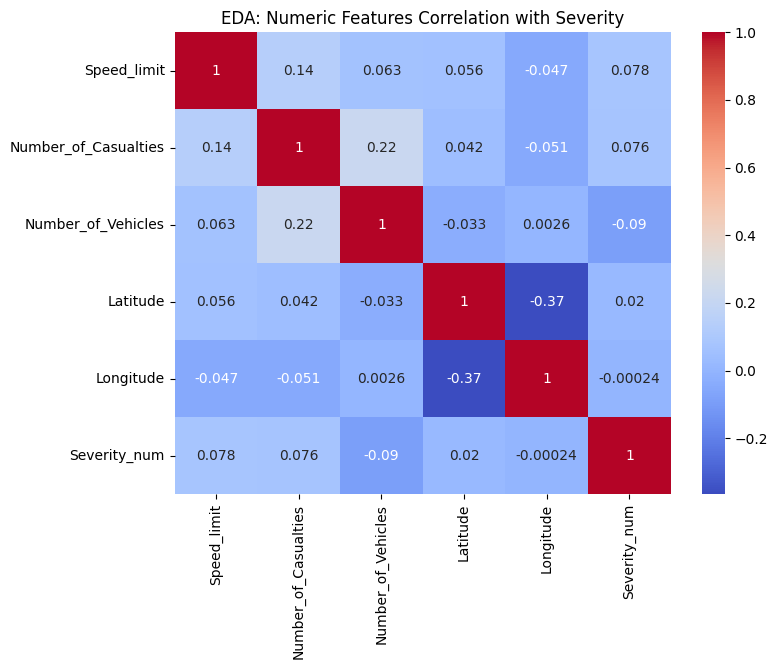

In [213]:
numeric_cols = [
    "Speed_limit",
    "Number_of_Casualties",
    "Number_of_Vehicles",
    "Latitude",
    "Longitude",
    "Severity_num"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("EDA: Numeric Features Correlation with Severity")
plt.show()


In [215]:
df.groupby("Severity_3")["Number_of_Casualties"].mean()


Severity_3
Fatal      1.804958
Serious    1.455866
Slight     1.334837
Name: Number_of_Casualties, dtype: float64

In [216]:
df_model.to_csv("df_model_ready.csv", index=False)
print("CSV güncellendi ✅")


CSV güncellendi ✅


In [217]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 43 columns):
 #   Column                                    Non-Null Count   Dtype   
---  ------                                    --------------   -----   
 0   Latitude                                  307973 non-null  float64 
 1   Light_Conditions                          307973 non-null  object  
 2   Longitude                                 307973 non-null  float64 
 3   Number_of_Casualties                      307973 non-null  int64   
 4   Number_of_Vehicles                        307973 non-null  float64 
 5   Speed_limit                               307973 non-null  int64   
 6   Urban_or_Rural_Area                       307973 non-null  int64   
 7   Severity_3                                307973 non-null  object  
 8   Year                                      307973 non-null  int32   
 9   Month                                     307973 non-null  int32   
 10  Day     

In [218]:
df["Severity_num"].value_counts()

Severity_num
0    263280
1     40740
2      3953
Name: count, dtype: int64

In [219]:
df_model.to_csv("df_model_hazır.csv", index=False)
print("df_model_hazır.csv kaydedildi ✅")

df_model_hazır.csv kaydedildi ✅


In [221]:
df.columns

Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Longitude', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions',
       'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area',
       'Weather_Conditions', 'Vehicle_Type', 'Severity_3', 'Severity_num'],
      dtype='object')

In [222]:
df["Severity_num"].value_counts()


Severity_num
0    263280
1     40740
2      3953
Name: count, dtype: int64

In [223]:
print(df.columns.tolist())

['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type', 'Severity_3', 'Severity_num']


In [226]:
severity_map = {
    "Slight": 0,
    "Serious": 1,
    "Fatal": 2
}

df_model["Severity_num"] = df_model["Severity_3"].map(severity_map)

# kontrol
df_model["Severity_num"].value_counts()


Severity_num
0    263280
1     40740
2      3953
Name: count, dtype: int64

In [227]:
df_model.to_csv("df_model_hazır2.csv", index=False)
print("CSV güncellendi")


CSV güncellendi kral 👑


In [228]:
df_model["Severity_num"].value_counts()

Severity_num
0    263280
1     40740
2      3953
Name: count, dtype: int64

In [231]:
df_model["Severity_num"].value_counts()

Severity_num
0    263280
1     40740
2      3953
Name: count, dtype: int64

In [234]:
df_model = pd.get_dummies(df_model, columns=["Speed_Category"], drop_first=True)

In [235]:
df_model = df_model.drop(columns=["Light_Conditions"])

In [236]:
df_model = df_model.drop(columns=["Severity_3"])

In [238]:
df_model.to_csv("df_model_hazır3.csv", index=False)
print("CSV güncellendi kral 👑")

CSV güncellendi kral 👑


In [239]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 43 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Latitude                                  307973 non-null  float64
 1   Longitude                                 307973 non-null  float64
 2   Number_of_Casualties                      307973 non-null  int64  
 3   Number_of_Vehicles                        307973 non-null  float64
 4   Speed_limit                               307973 non-null  int64  
 5   Urban_or_Rural_Area                       307973 non-null  int64  
 6   Year                                      307973 non-null  int32  
 7   Month                                     307973 non-null  int32  
 8   Day                                       307973 non-null  int32  
 9   Weekday                                   307973 non-null  int32  
 10  Hour                

In [240]:
df_model2 = df_model.copy()


In [241]:
df_model2["Speed_Night"] = df_model2["Speed_limit"] * df_model2["Is_Night"]
df_model2["Speed_RushHour"] = df_model2["Speed_limit"] * df_model2["Is_Rush_Hour"]


In [242]:
df_model2["Speed_Vulnerable"] = (
    df_model2["Speed_limit"] * df_model2["Vehicle_Group_Vulnerable"]
)


In [243]:
df_model2["Night_BadWeather"] = (
    df_model2["Is_Night"] * df_model2["Bad_Weather"]
)

df_model2["Speed_BadWeather"] = (
    df_model2["Speed_limit"] * df_model2["Bad_Weather"]
)


In [244]:
junction_flag = (
    df_model2["Junction_Detail_Grouped_Simple_Junction"] |
    df_model2["Junction_Detail_Grouped_Roundabout"]
).astype(int)

df_model2["Speed_Junction"] = df_model2["Speed_limit"] * junction_flag


In [245]:
df_model2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 49 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Latitude                                  307973 non-null  float64
 1   Longitude                                 307973 non-null  float64
 2   Number_of_Casualties                      307973 non-null  int64  
 3   Number_of_Vehicles                        307973 non-null  float64
 4   Speed_limit                               307973 non-null  int64  
 5   Urban_or_Rural_Area                       307973 non-null  int64  
 6   Year                                      307973 non-null  int32  
 7   Month                                     307973 non-null  int32  
 8   Day                                       307973 non-null  int32  
 9   Weekday                                   307973 non-null  int32  
 10  Hour                

In [246]:
df_model2.to_csv("processed_v2.csv", index=False)


In [247]:
df_model.shape, df_model2.shape


((307973, 43), (307973, 49))